## DROID Dataset Hacking
- Extract language instructions / prompts from the full DROID dataset
- Render session visualizations (cameras + control signals + metadata)
- Data source: `aractingi/droid_1.0.1` on HuggingFace (LeRobot v3 format)

In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm import tqdm
import json
import cv2
from huggingface_hub import hf_hub_download

In [12]:
REPO = 'aractingi/droid_1.0.1'
SAVE_DIR = 'droid_renders'
os.makedirs(SAVE_DIR, exist_ok=True)

CAMERAS = [
    'observation.images.exterior_1_left',
    'observation.images.exterior_2_left',
    'observation.images.wrist_left',
]

## Part 1: Extract All Language Instructions
Download parquet metadata from HuggingFace (no video needed — fast).

In [13]:
print('Downloading episode metadata...')
ep_meta = pd.read_parquet(hf_hub_download(REPO, 'meta/episodes/chunk-000/file-000.parquet', repo_type='dataset'))
print('Downloading data parquet...')
data_df = pd.read_parquet(hf_hub_download(REPO, 'data/chunk-000/file-000.parquet', repo_type='dataset'))

valid_ep_indices = sorted(data_df['episode_index'].unique().tolist())
print(f'{len(valid_ep_indices)} episodes with data in chunk-000')
print(f'{ep_meta["episode_index"].nunique()} episodes in metadata')

1074 episodes with data in chunk-000
14153 episodes in metadata


In [14]:
# Extract language instructions for all episodes with data
instructions = []
for ep_idx in valid_ep_indices:
    row = data_df[data_df['episode_index'] == ep_idx].iloc[0]
    instructions.append({
        'episode_index': int(ep_idx),
        'language_instruction': row['language_instruction'] or '',
        'language_instruction_2': row['language_instruction_2'] or '',
        'language_instruction_3': row['language_instruction_3'] or '',
    })

# Save
with open(os.path.join(SAVE_DIR, 'language_instructions.json'), 'w') as f:
    json.dump(instructions, f, indent=2)

unique = sorted(set(d['language_instruction'] for d in instructions if d['language_instruction']))
print(f'Saved {len(instructions)} episodes, {len(unique)} unique instructions')
for inst in unique[:20]:
    print(f'  - {inst}')

Saved 1074 episodes, 815 unique instructions
  - Attach the electric toothbrush to its charging port
  - Change the position of the marker to face across the table
  - Click the button on the mouse.
  - Close the MacBook
  - Close the black watering can
  - Close the bottom drawer of the right cabinet
  - Close the bottom drawer on the left
  - Close the bottom left cabinet door
  - Close the brown box.
  - Close the cabinet drawer on the left
  - Close the coffeemaker
  - Close the curtain
  - Close the door
  - Close the doors to the two compartments
  - Close the drawer
  - Close the first top drawer
  - Close the laptop
  - Close the lid of the coffee maker
  - Close the microwave door
  - Close the open drawer


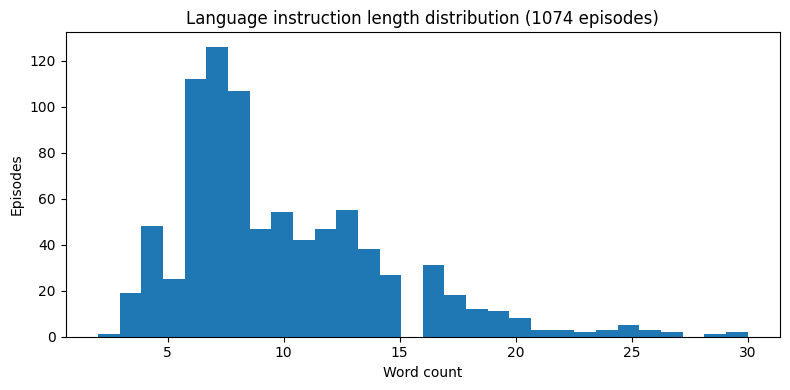

In [15]:
# Distribution of instruction lengths
lens = [len(d['language_instruction'].split()) for d in instructions if d['language_instruction']]
plt.figure(figsize=(8, 4))
plt.hist(lens, bins=30)
plt.xlabel('Word count')
plt.ylabel('Episodes')
plt.title(f'Language instruction length distribution ({len(instructions)} episodes)')
plt.tight_layout()
plt.show()

## Part 2: Episode Extraction & Rendering
Helper functions to download video frames and render episodes.

In [16]:
def load_video_frames(vid_path, from_ts, to_ts, fps=15):
    """Extract frames between from_ts and to_ts (seconds) from a video file."""
    cap = cv2.VideoCapture(vid_path)
    cap.set(cv2.CAP_PROP_POS_MSEC, from_ts * 1000)
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        pos = cap.get(cv2.CAP_PROP_POS_MSEC) / 1000.0
        if pos > to_ts + 1 / fps:
            break
        frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()
    return np.stack(frames) if frames else np.zeros((1, 180, 320, 3), dtype=np.uint8)


# Cache for downloaded video files
_vid_cache = {}

def get_vid_path(chunk_idx, file_idx, cam):
    key = (chunk_idx, file_idx, cam)
    if key not in _vid_cache:
        remote = f'videos/{cam}/chunk-{chunk_idx:03d}/file-{file_idx:03d}.mp4'
        print(f'    downloading {remote}...', end=' ', flush=True)
        import time; t0 = time.time()
        _vid_cache[key] = hf_hub_download(REPO, remote, repo_type='dataset')
        print(f'{time.time()-t0:.1f}s')
    return _vid_cache[key]


def extract_episode(ep_idx):
    """Download and extract all data for one episode."""
    ep = ep_meta[ep_meta['episode_index'] == ep_idx].iloc[0]
    ep_data = data_df[data_df['episode_index'] == ep_idx].reset_index(drop=True)

    lang  = ep_data.iloc[0]['language_instruction'] or ''
    lang2 = ep_data.iloc[0]['language_instruction_2'] or ''
    lang3 = ep_data.iloc[0]['language_instruction_3'] or ''

    cam_frames = {}
    for cam in CAMERAS:
        ci = int(ep[f'videos/{cam}/chunk_index'])
        fi = int(ep[f'videos/{cam}/file_index'])
        from_ts = ep[f'videos/{cam}/from_timestamp']
        to_ts   = ep[f'videos/{cam}/to_timestamp']
        vpath = get_vid_path(ci, fi, cam)
        cam_frames[cam] = load_video_frames(vpath, from_ts, to_ts)

    actions     = np.stack(ep_data['action'].tolist())
    gripper_pos = np.array(ep_data['observation.state.gripper_position'].tolist())

    return {
        'lang': lang, 'lang2': lang2, 'lang3': lang3,
        'file_path': f'ep_{ep_idx}',
        'ext1':  cam_frames[CAMERAS[0]],
        'ext2':  cam_frames[CAMERAS[1]],
        'wrist': cam_frames[CAMERAS[2]],
        'actions': actions,
        'gripper_pos': gripper_pos.reshape(-1, 1),
    }

print('Helper functions defined')

Helper functions defined


In [17]:
def render_episode_mp4(ep_data, out_path, fps=15):
    """Fast episode render: cameras on top, pre-rendered action plots on bottom.
    Uses cv2 for frame compositing (matplotlib only called once for the static plot)."""
    T_frames = ep_data['ext1'].shape[0]
    T_actions = ep_data['actions'].shape[0]
    T = min(T_frames, T_actions)

    n_act = ep_data['actions'].shape[1]
    lang = ep_data['lang'] or ep_data.get('lang2', '') or ep_data.get('lang3', '') or '(no instruction)'

    actions = ep_data['actions'][:T]
    gripper_pos = ep_data['gripper_pos'][:T]
    t_axis = np.arange(T)

    # Pre-render action plots as a single static image (one matplotlib call)
    act_labels = ['act_0', 'act_1', 'act_2', 'act_3', 'act_4', 'act_5', 'act_6', 'grip_pos']
    fig, axes_arr = plt.subplots(2, 4, figsize=(16, 4), dpi=80)
    axes_flat = axes_arr.flatten()
    for i in range(min(n_act, 7)):
        axes_flat[i].plot(t_axis, actions[:, i], color='steelblue', lw=1)
        axes_flat[i].set_title(act_labels[i], fontsize=8)
        axes_flat[i].tick_params(labelsize=5)
        axes_flat[i].set_xlim(0, T - 1)
    axes_flat[7].plot(t_axis, gripper_pos[:, 0], color='darkorange', lw=1)
    axes_flat[7].set_title('grip_pos', fontsize=8)
    axes_flat[7].tick_params(labelsize=5)
    axes_flat[7].set_xlim(0, T - 1)
    plt.tight_layout()
    fig.canvas.draw()
    plot_w, plot_h = fig.canvas.get_width_height()
    plot_img = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8).reshape(plot_h, plot_w, 4)[:, :, :3].copy()

    # Get cursor pixel ranges from subplot positions
    cursor_info = []
    for i in range(8):
        bbox = axes_flat[i].get_position()
        x_left = int(bbox.x0 * plot_w)
        x_right = int(bbox.x1 * plot_w)
        y_top = int((1 - bbox.y0) * plot_h)
        y_bot = int((1 - bbox.y1) * plot_h)
        cursor_info.append((x_left, x_right, y_bot, y_top))
    plt.close(fig)

    # Frame layout: cameras on top, text bar, plots on bottom
    cam_h, cam_w = ep_data['ext1'].shape[1], ep_data['ext1'].shape[2]
    cam_disp_w = plot_w // 3
    cam_disp_h = int(cam_h * cam_disp_w / cam_w)
    text_h = 40
    frame_h = cam_disp_h + text_h + plot_h
    frame_w = plot_w
    frame_h += frame_h % 2  # ensure even for h264
    frame_w += frame_w % 2

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(out_path, fourcc, fps, (frame_w, frame_h))

    for t in range(T):
        frame = np.zeros((frame_h, frame_w, 3), dtype=np.uint8)

        # 3 camera views side by side
        for ci, cam_key in enumerate(['ext1', 'ext2', 'wrist']):
            img = cv2.resize(ep_data[cam_key][min(t, T_frames-1)], (cam_disp_w, cam_disp_h))
            x_off = ci * cam_disp_w
            frame[0:cam_disp_h, x_off:x_off+cam_disp_w] = img[:, :, ::-1]  # RGB->BGR

        # Language instruction text
        cv2.putText(frame, lang[:100], (10, cam_disp_h + 25),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 1, cv2.LINE_AA)

        # Frame counter
        cv2.putText(frame, f'{t+1}/{T}', (frame_w - 120, cam_disp_h + 25),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (180, 180, 180), 1, cv2.LINE_AA)

        # Action plots with cursor
        plot_frame = plot_img.copy()
        frac = t / max(T - 1, 1)
        for (x_left, x_right, y_bot, y_top) in cursor_info:
            cx = int(x_left + frac * (x_right - x_left))
            cv2.line(plot_frame, (cx, y_bot), (cx, y_top), (0, 0, 255), 2)

        y_off = cam_disp_h + text_h
        frame[y_off:y_off+plot_h, 0:plot_w] = plot_frame[:, :, ::-1]  # RGB->BGR

        writer.write(frame)

    writer.release()

print('render_episode_mp4 defined')

render_episode_mp4 defined


## Part 3: Sanity Check
Load one episode, show cameras, test render.

    downloading videos/observation.images.exterior_1_left/chunk-000/file-000.mp4... 0.2s
    downloading videos/observation.images.exterior_2_left/chunk-000/file-000.mp4... 0.2s
    downloading videos/observation.images.wrist_left/chunk-000/file-000.mp4... 0.2s
lang: ''
ext1: (169, 180, 320, 3)   actions: (167, 8)


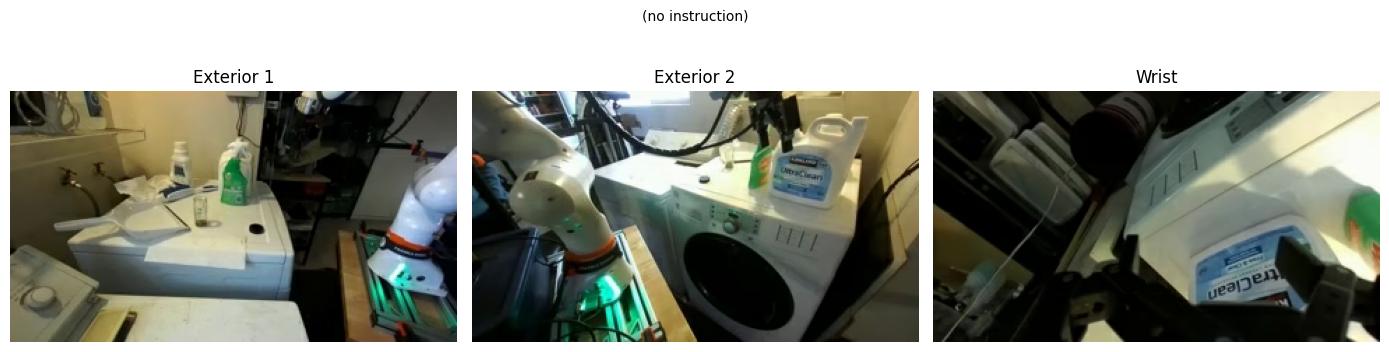

In [18]:
# Load and inspect one episode
ep_data = extract_episode(valid_ep_indices[0])
print('lang:', repr(ep_data['lang']))
print('ext1:', ep_data['ext1'].shape, '  actions:', ep_data['actions'].shape)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(ep_data['ext1'][0]);  axes[0].set_title('Exterior 1'); axes[0].axis('off')
axes[1].imshow(ep_data['ext2'][0]);  axes[1].set_title('Exterior 2'); axes[1].axis('off')
axes[2].imshow(ep_data['wrist'][0]); axes[2].set_title('Wrist');      axes[2].axis('off')
fig.suptitle(ep_data['lang'] or '(no instruction)', fontsize=10)
plt.tight_layout()
plt.show()

In [19]:
# Test render one episode
import time
t0 = time.time()
test_out = os.path.join(SAVE_DIR, 'test_episode.mp4')
render_episode_mp4(ep_data, test_out, fps=15)
print(f'Saved: {test_out} ({time.time()-t0:.1f}s)')

Saved: droid_renders/test_episode.mp4 (1.2s)


## Part 4: Render 500 Episodes
Sample 500 random episodes and render MP4 for each.

In [20]:
import random, time
random.seed(42)

N_RENDER = min(500, len(valid_ep_indices))
sampled_eps = random.sample(valid_ep_indices, N_RENDER)
print(f'Will render {N_RENDER} episodes from {len(valid_ep_indices)} available')

failed = []
for rank, ep_idx in enumerate(sampled_eps):
    out_path = os.path.join(SAVE_DIR, f'episode_{rank:04d}.mp4')
    if os.path.exists(out_path):
        continue

    t0 = time.time()
    print(f'[{rank+1}/{N_RENDER}] ep={ep_idx}', end=' ', flush=True)
    try:
        ep_data = extract_episode(ep_idx)
        T = min(ep_data['ext1'].shape[0], ep_data['actions'].shape[0])
        print(f'{T}fr lang={repr(ep_data["lang"][:40])}', end=' ', flush=True)
        render_episode_mp4(ep_data, out_path, fps=15)
        print(f'ok ({time.time()-t0:.1f}s)')
    except Exception as e:
        print(f'FAILED: {e}')
        failed.append(ep_idx)

print(f'\nDone. {N_RENDER - len(failed)} rendered, {len(failed)} failed.')

Will render 500 episodes from 1074 available
[1/500] ep=228 241fr lang='Remove the knife from the cup' ok (1.8s)
[2/500] ep=51 202fr lang='Put the towel on the seat of the chair' ok (1.6s)
[3/500] ep=563     downloading videos/observation.images.exterior_1_left/chunk-000/file-001.mp4... 0.2s
    downloading videos/observation.images.exterior_2_left/chunk-000/file-001.mp4... 0.2s
    downloading videos/observation.images.wrist_left/chunk-000/file-001.mp4... 0.3s
600fr lang='Pour the coffee beans from the white pla' ok (4.9s)
[4/500] ep=501 97fr lang='' ok (0.9s)
[5/500] ep=457 106fr lang='Press a button on the coffee maker' ok (1.1s)
[6/500] ep=285 146fr lang='Turn the coffee machine by pushing the h' ok (1.1s)
[7/500] ep=209 260fr lang='Move the takeaway pack to the top right' ok (1.7s)
[8/500] ep=178 490fr lang='Remove the plate from the oven the use t' ok (3.2s)
[9/500] ep=864     downloading videos/observation.images.exterior_1_left/chunk-000/file-002.mp4... 0.3s
    downloading vid